### **1. Import Library**

In [1]:
# First let's import the packages we will use in this project
# You can do this all now or as you need them

import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt

### **2. Data Connection**

In [2]:
# I use postgresql for connection via DBeaver

load_dotenv()

user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
db = os.getenv('DB_NAME')

connection_string = f'postgresql://{user}:{password}@{host}:{port}/{db}'
engine = create_engine(connection_string, pool_pre_ping=True)

try:
    df = pd.read_sql("SELECT * FROM bike_sales.v_bike_sales", engine)
    print("Connection Successful!")
except Exception as e:
    print(f"Connection Failed: {e}")

Connection Successful!


### **3. Data Cleaning**

In [3]:
# Preview the first few rows to understand the structure of the data
df.head()

,order_id,customers,city,state,order_date,total_units,revenue,unit_price,product_name,category_name,brand_name,store_name,sales_rep
0,672,Delmar Wise,Lockport,NY,2019-02-01,2,2999.98,1499.99,Trek Emonda S 4 - 2017,Road Bikes,Trek,Baldwin Bikes,Marcelene Boyer
1,751,Hilary Savage,Oxnard,CA,2017-05-03,2,1739.98,869.99,Haro SR 1.2 - 2017,Mountain Bikes,Haro,Santa Cruz Bikes,Genna Serrano
2,862,Jesus Burch,Desoto,TX,2019-03-04,1,329.99,329.99,Haro Downtown 16 - 2017,Children Bicycles,Haro,Rowlett Bikes,Kali Vargas
3,993,Harold O'connor,Santa Cruz,CA,2017-09-07,1,4999.99,4999.99,Trek Madone 9.2 - 2017,Road Bikes,Trek,Santa Cruz Bikes,Genna Serrano
4,1137,Ivelisse Nixon,Houston,TX,2018-08-09,2,9999.98,4999.99,Trek Madone 9.2 - 2017,Road Bikes,Trek,Rowlett Bikes,Kali Vargas


In [4]:
# Get an initial summary: column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4555 entries, 0 to 4554
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       4555 non-null   int64  
 1   customers      4555 non-null   object 
 2   city           4555 non-null   object 
 3   state          4555 non-null   object 
 4   order_date     4555 non-null   object 
 5   total_units    4555 non-null   int64  
 6   revenue        4555 non-null   float64
 7   unit_price     4555 non-null   float64
 8   product_name   4555 non-null   object 
 9   category_name  4555 non-null   object 
 10  brand_name     4555 non-null   object 
 11  store_name     4555 non-null   object 
 12  sales_rep      4555 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 462.7+ KB


In [5]:
# Convert order_date to datetime for time-based analysis
df['order_date'] = pd.to_datetime(df['order_date'])

In [6]:
# Confirm the dtype conversion was successful
df.dtypes

order_id                  int64
customers                object
city                     object
state                    object
order_date       datetime64[ns]
total_units               int64
revenue                 float64
unit_price              float64
product_name             object
category_name            object
brand_name               object
store_name               object
sales_rep                object
dtype: object

In [7]:
# Check for missing values across all columns
df.isnull().sum()

order_id         0
customers        0
city             0
state            0
order_date       0
total_units      0
revenue          0
unit_price       0
product_name     0
category_name    0
brand_name       0
store_name       0
sales_rep        0
dtype: int64

In [8]:
# Check for duplicate rows, critical to avoid double-counting in aggregations
df.duplicated().sum()

np.int64(0)

In [9]:
# Review the number of unique values per column to spot data consistency issues
df.nunique()

order_id         1557
customers        1417
city              195
state               3
order_date        485
total_units         2
revenue           196
unit_price        101
product_name      270
category_name       7
brand_name          9
store_name          3
sales_rep           6
dtype: int64

In [10]:
# Check for negative or zero values in numeric columns, these would indicate data entry errors
print('Negative revenue   :', (df['revenue'] < 0).sum())
print('Zero revenue       :', (df['revenue'] == 0).sum())
print('Negative units     :', (df['total_units'] < 0).sum())
print('Zero unit price    :', (df['unit_price'] == 0).sum())

Negative revenue   : 0
Zero revenue       : 0
Negative units     : 0
Zero unit price    : 0


In [11]:
# Validate revenue consistency: revenue should equal unit_price x total_units
# A discrepancy may indicate rounding, bundling, or data entry issues
df['calculated_revenue'] = df['unit_price'] * df['total_units']
df['revenue_discrepancy'] = abs(df['revenue'] - df['calculated_revenue'])
print('Discrepancies found (diff > 0.01):', (df['revenue_discrepancy'] > 0.01).sum())
df.drop(columns=['calculated_revenue', 'revenue_discrepancy'], inplace=True)

Discrepancies found (diff > 0.01): 0


In [12]:
# Confirm the date range is within the expected analysis period (2016-2019)
print('Earliest order date :', df['order_date'].min().date())
print('Latest order date   :', df['order_date'].max().date())

Earliest order date : 2016-01-01
Latest order date   : 2019-12-04


In [13]:
# Inspect unique values in categorical columns to detect unexpected entries,
# misspellings, or inconsistencies in naming
for col in ['state', 'store_name', 'brand_name', 'category_name']:
    print(f'\n{col} ({df[col].nunique()} unique):')
    print(sorted(df[col].unique()))


state (3 unique):
['CA', 'NY', 'TX']

store_name (3 unique):
['Baldwin Bikes', 'Rowlett Bikes', 'Santa Cruz Bikes']

brand_name (9 unique):
['Electra', 'Haro', 'Heller', 'Pure Cycles', 'Ritchey', 'Strider', 'Sun Bicycles', 'Surly', 'Trek']

category_name (7 unique):
['Children Bicycles', 'Comfort Bicycles', 'Cruisers Bicycles', 'Cyclocross Bicycles', 'Electric Bikes', 'Mountain Bikes', 'Road Bikes']


**Data Cleaning Summary**

- No missing values found across all columns
- No duplicate rows detected
- No negative or zero values in revenue, units, or price fields
- Revenue consistency check passed, no discrepancies between revenue and unit_price × total_units
- Date range confirmed: January 2016 to December 2019
- All categorical columns show clean, consistent values with no anomalies

> Data is clean and ready for exploratory analysis.

In [14]:
# Final confirmation — verify data types and shape after all cleaning steps
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4555 entries, 0 to 4554
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       4555 non-null   int64         
 1   customers      4555 non-null   object        
 2   city           4555 non-null   object        
 3   state          4555 non-null   object        
 4   order_date     4555 non-null   datetime64[ns]
 5   total_units    4555 non-null   int64         
 6   revenue        4555 non-null   float64       
 7   unit_price     4555 non-null   float64       
 8   product_name   4555 non-null   object        
 9   category_name  4555 non-null   object        
 10  brand_name     4555 non-null   object        
 11  store_name     4555 non-null   object        
 12  sales_rep      4555 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(8)
memory usage: 462.7+ KB


In [15]:
# Confirm first rows look correct after cleaning
df.head()

,order_id,customers,city,state,order_date,total_units,revenue,unit_price,product_name,category_name,brand_name,store_name,sales_rep
0,672,Delmar Wise,Lockport,NY,2019-02-01,2,2999.98,1499.99,Trek Emonda S 4 - 2017,Road Bikes,Trek,Baldwin Bikes,Marcelene Boyer
1,751,Hilary Savage,Oxnard,CA,2017-05-03,2,1739.98,869.99,Haro SR 1.2 - 2017,Mountain Bikes,Haro,Santa Cruz Bikes,Genna Serrano
2,862,Jesus Burch,Desoto,TX,2019-03-04,1,329.99,329.99,Haro Downtown 16 - 2017,Children Bicycles,Haro,Rowlett Bikes,Kali Vargas
3,993,Harold O'connor,Santa Cruz,CA,2017-09-07,1,4999.99,4999.99,Trek Madone 9.2 - 2017,Road Bikes,Trek,Santa Cruz Bikes,Genna Serrano
4,1137,Ivelisse Nixon,Houston,TX,2018-08-09,2,9999.98,4999.99,Trek Madone 9.2 - 2017,Road Bikes,Trek,Rowlett Bikes,Kali Vargas


In [16]:
# Confirm last rows, ensure no trailing anomalies
df.tail()

,order_id,customers,city,state,order_date,total_units,revenue,unit_price,product_name,category_name,brand_name,store_name,sales_rep
4550,1612,Tameka Fisher,Redondo Beach,CA,2019-09-10,2,679.98,339.99,Electra Townie 7D (20-inch) - Boys' - 2017,Children Bicycles,Electra,Santa Cruz Bikes,Genna Serrano
4551,1612,Tameka Fisher,Redondo Beach,CA,2019-09-10,1,699.99,699.99,Electra Townie Commute 8D Ladies' - 2018,Cruisers Bicycles,Electra,Santa Cruz Bikes,Genna Serrano
4552,1612,Tameka Fisher,Redondo Beach,CA,2019-09-10,1,1559.99,1559.99,Sun Bicycles ElectroLite - 2017,Electric Bikes,Sun Bicycles,Santa Cruz Bikes,Genna Serrano
4553,1613,Debra Burks,Orchard Park,NY,2019-06-11,2,639.98,319.99,Electra Heartchya 1 (20-inch) - Girl's - 2018,Children Bicycles,Electra,Baldwin Bikes,Marcelene Boyer
4554,1613,Debra Burks,Orchard Park,NY,2019-06-11,1,4999.99,4999.99,Trek Domane SL 7 Women's - 2018,Road Bikes,Trek,Baldwin Bikes,Marcelene Boyer


### **4. Exploratory Data Analysis**

In [17]:
# Descriptive statistics give us an initial sense of distribution,
# central tendency, and spread for all numeric columns
df.describe()

,order_id,order_date,total_units,revenue,unit_price
count,4555.000000,4555,4555.000000,4555.000000,4555.000000
mean,796.271789,2017-12-24 13:05:35.894621184,1.498793,1795.713985,1199.833396
min,1.000000,2016-01-01 00:00:00,1.000000,89.990000,89.990000
25%,408.000000,2017-04-12 00:00:00,1.000000,539.980000,429.000000
50%,803.000000,2018-01-11 00:00:00,1.000000,939.980000,599.990000
75%,1183.500000,2018-09-08 00:00:00,2.000000,1999.980000,1549.000000
max,1613.000000,2019-12-04 00:00:00,2.000000,23999.980000,11999.990000
std,454.225326,NaN,0.500053,2194.557982,1338.997974


#### **4.1 Outlier Analysis and Handling**

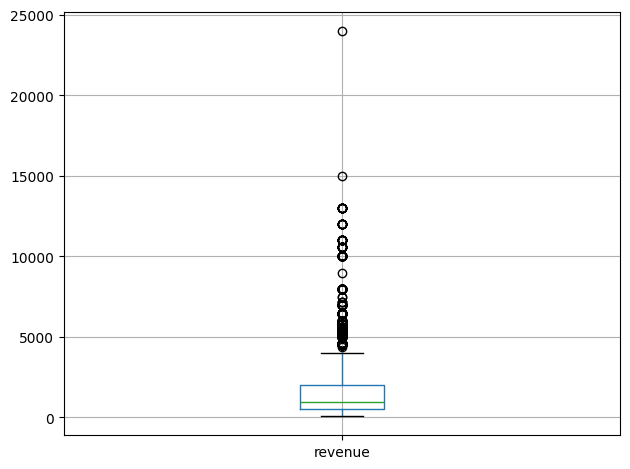

In [18]:
# Outlier check
df.boxplot(column='revenue')
plt.tight_layout()
plt.show()

In [19]:
# Identify the product that caused the extreme outlier
df[df['revenue'] > 20000]

,order_id,customers,city,state,order_date,total_units,revenue,unit_price,product_name,category_name,brand_name,store_name,sales_rep
4410,1541,Pamelia Newman,Monroe,NY,2019-04-04,2,23999.98,11999.99,Trek Domane SLR 9 Disc - 2018,Road Bikes,Trek,Baldwin Bikes,Venita Daniel


Validation with market data:
To confirm the **extreme outlier ($23,999.98)**, I cross-referenced the product with real market prices. The image below shows that the 'Trek Domane SLR 9 Disc' has a Manufacturer Price of $11,999. Since the order contains 2 units, the total revenue of ~$24,000 is **100% accurate and valid**.

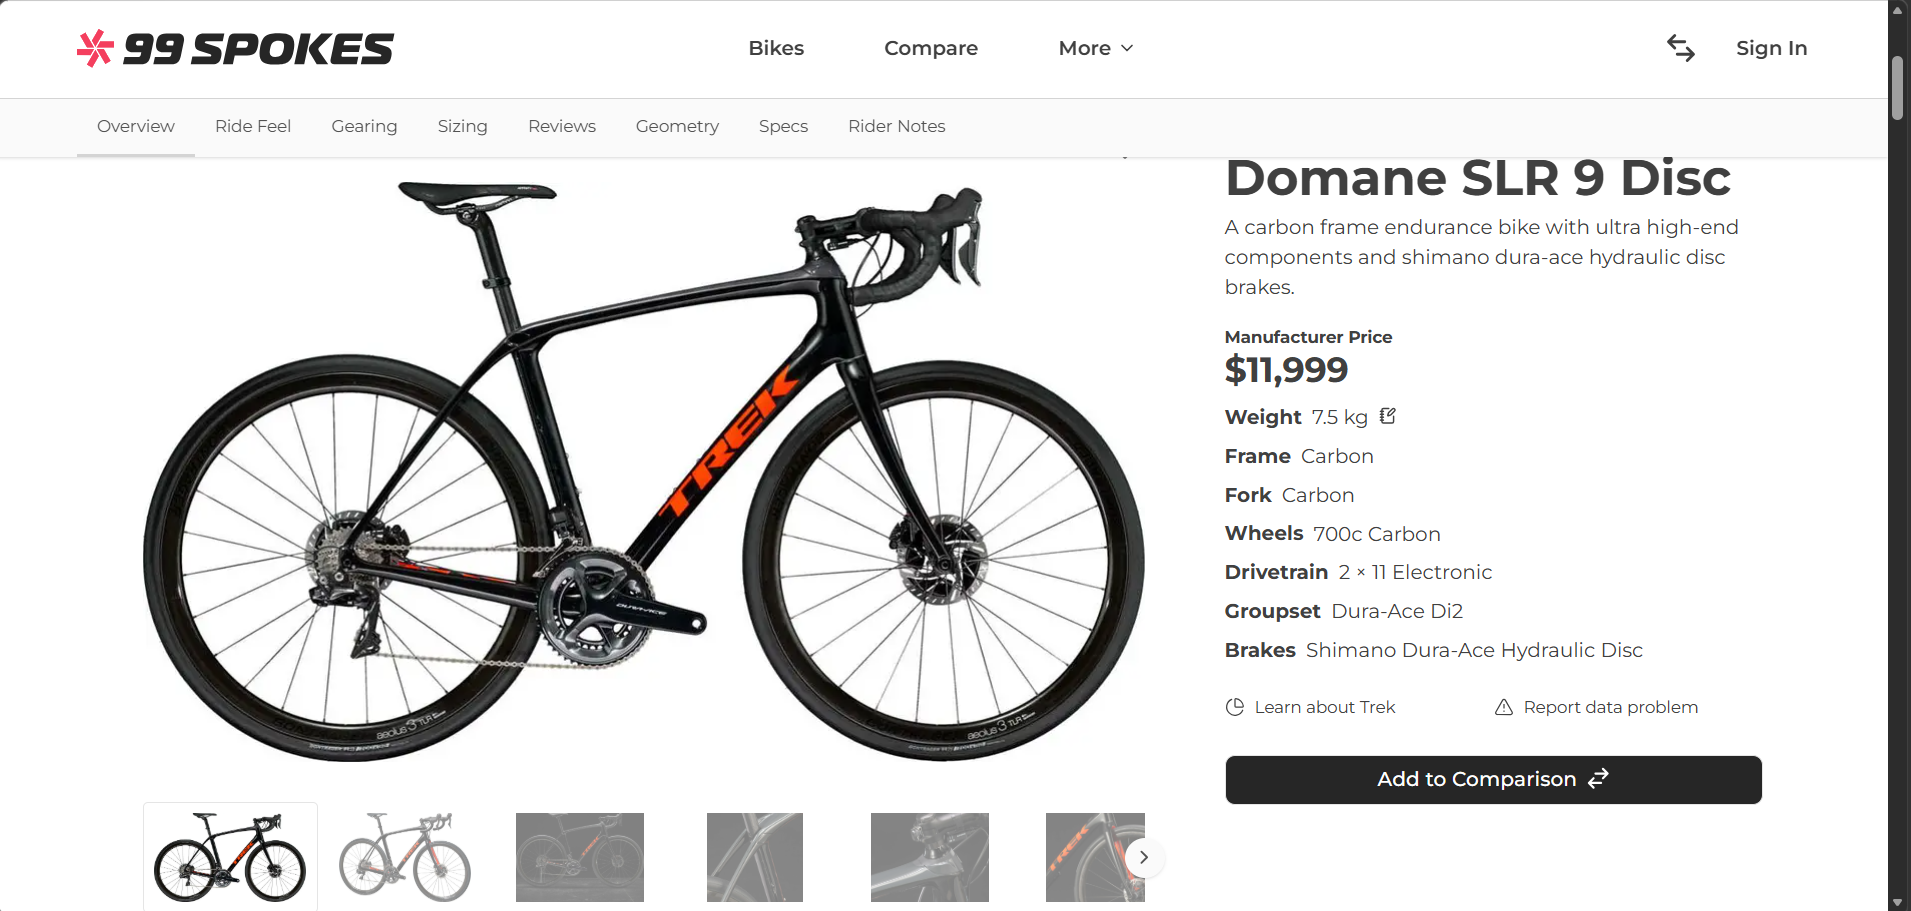
> ***Source:*** *[99spokes.com](https://99spokes.com/en/bikes/trek/2018/domane-slr-9-disc)*

In [20]:
# Use the IQR method to identify outliers on both sides
# Lower bound catches unusually cheap transactions, upper bound catches premium ones
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'IQR          : {IQR:.2f}')
print(f'Lower bound  : {lower_bound:.2f}')
print(f'Upper bound  : {upper_bound:.2f}')
print(f'Outliers below lower bound : {(df["revenue"] < lower_bound).sum()}')
print(f'Outliers above upper bound : {(df["revenue"] > upper_bound).sum()}')

IQR          : 1460.00
Lower bound  : -1650.02
Upper bound  : 4189.98
Outliers below lower bound : 0
Outliers above upper bound : 503


In [21]:
# This is the outliers data
outliers = df[df['revenue'] > upper_bound]
outliers

,order_id,customers,city,state,order_date,total_units,revenue,unit_price,product_name,category_name,brand_name,store_name,sales_rep
3,993,Harold O'connor,Santa Cruz,CA,2017-09-07,1,4999.99,4999.99,Trek Madone 9.2 - 2017,Road Bikes,Trek,Santa Cruz Bikes,Genna Serrano
4,1137,Ivelisse Nixon,Houston,TX,2018-08-09,2,9999.98,4999.99,Trek Madone 9.2 - 2017,Road Bikes,Trek,Rowlett Bikes,Kali Vargas
23,6,Sharyn Hopkins,Baldwinsville,NY,2016-04-01,2,5999.98,2999.99,Trek Conduit+ - 2016,Electric Bikes,Trek,Baldwin Bikes,Marcelene Boyer
29,9,Neil Mccall,San Carlos,CA,2016-05-01,2,7999.98,3999.99,Trek Slash 8 27.5 - 2016,Mountain Bikes,Trek,Santa Cruz Bikes,Mireya Copeland
35,12,Marvin Mullins,San Diego,CA,2016-06-01,2,5799.98,2899.99,Trek Fuel EX 8 29 - 2016,Mountain Bikes,Trek,Santa Cruz Bikes,Mireya Copeland
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4520,1577,Cesar Jackson,Liverpool,NY,2019-11-04,2,5198.00,2599.00,Heller Bloodhound Trail - 2018,Mountain Bikes,Heller,Baldwin Bikes,Venita Daniel
4524,1578,Corrina Sawyer,Troy,NY,2019-11-04,2,7199.98,3599.99,Trek Super Commuter+ 7 - 2018,Electric Bikes,Trek,Baldwin Bikes,Venita Daniel
4534,1605,Robena Hill,Corpus Christi,TX,2018-01-07,1,4499.99,4499.99,Trek CrossRip+ - 2018,Electric Bikes,Trek,Rowlett Bikes,Kali Vargas
4547,1611,Lyndsey Bean,Fairport,NY,2018-06-09,2,6399.98,3199.99,Trek Domane SL 6 - 2018,Road Bikes,Trek,Baldwin Bikes,Venita Daniel


In [22]:
# Analyze outliers by category — revenue share, transaction count, and price range
outlier_analysis = outliers.groupby('category_name')['revenue'].agg(
    total_revenue='sum',
    transaction_count='count',
    avg_revenue='mean',
    min_revenue='min',
    max_revenue='max'
).sort_values(by='total_revenue', ascending=False)

outlier_analysis['revenue_share_%'] = (
    outlier_analysis['total_revenue'] / outlier_analysis['total_revenue'].sum() * 100
).round(1)

outlier_analysis

,total_revenue,transaction_count,avg_revenue,min_revenue,max_revenue,revenue_share_%
category_name,,,,,,
Road Bikes,1329697.15,174,7641.937644,4399.98,23999.98,37.3
Mountain Bikes,1311894.49,192,6832.783802,4499.98,10599.98,36.8
Electric Bikes,696198.07,104,6694.212212,4499.99,9999.98,19.5
Cyclocross Bicycles,195999.44,28,6999.980000,5999.98,7999.98,5.5
Cruisers Bicycles,23999.92,4,5999.980000,5999.98,5999.98,0.7
Comfort Bicycles,5199.98,1,5199.980000,5199.98,5199.98,0.1


In [23]:
# Price range per category — explains why certain categories dominate the outlier group
# avg_price is the key metric: higher avg price = more transactions crossing the upper bound
df.groupby('category_name')['unit_price'].agg(['mean', 'min', 'max']).sort_values(by='mean', ascending=False)

,mean,min,max
category_name,,,
Road Bikes,3313.847820,749.99,11999.99
Electric Bikes,3185.336535,1559.99,4999.99
Cyclocross Bicycles,2017.098353,1549.00,3999.99
Mountain Bikes,1722.287057,379.99,5299.99
Cruisers Bicycles,535.628062,250.99,2999.99
Comfort Bicycles,535.115483,416.99,2599.99
Children Bicycles,278.510000,89.99,489.99


Outlier Data Conclusion:

There are **503 outlier transactions** (revenue > 4,189). Some important reasons to keep this data:

1. These sales are not input errors or mistakes. They represent high priced bikes like the Trek Domane SLR 9, which costs around 12,000 per unit.
2. These 503 rows cover about 11% of the total data. Deleting them would remove valid transactions that are the most profitable.
3. This data shows that we have high value customers.

Outliers are dominated by Road Bikes and Mountain Bikes. Mountain Bikes have the highest number of outlier transactions, but Road Bikes contribute higher total revenue. This is because Road Bikes have a higher price range and are more expensive.

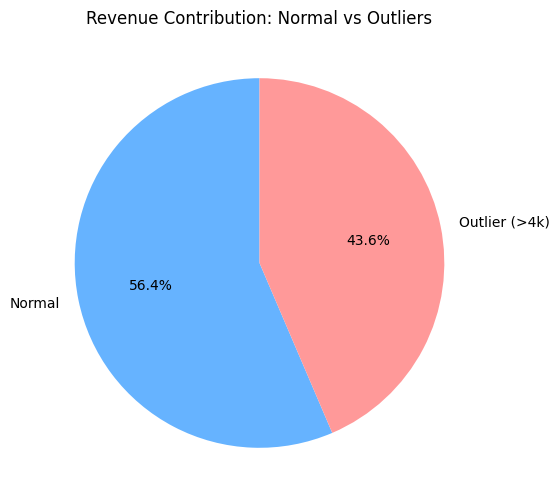

In [24]:
# We check the contribution of outliers to revenue
df['sales_group'] = df['revenue'].apply(lambda x: 'Outlier (>4k)' if x > 4189 else 'Normal')

contribution = df.groupby('sales_group')['revenue'].sum()

contribution.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'], figsize=(8,6))
plt.title('Revenue Contribution: Normal vs Outliers')
plt.ylabel('')
plt.show()

**Revenue Contribution Analysis**

1. While outliers (transactions > $4,189) only represent 11% of total orders, they contribute a massive 43.6% of our total revenue.
2. Business Impact: This confirms that high-end products (such as the Trek Domane SLR 9) are the main drivers of the company's income. Keeping these "outliers" in the analysis is crucial because they represent the actual financial performance of the business.

### **4.2 Comprehensive Sales Performance Analysis (2016–2019)**

#### **4.2.1 Yearly Revenue Trend & YoY Growth**

C:\Users\muham\AppData\Local\Temp\ipykernel_21376\1939267474.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df_trend['revenue'].resample('M').sum()


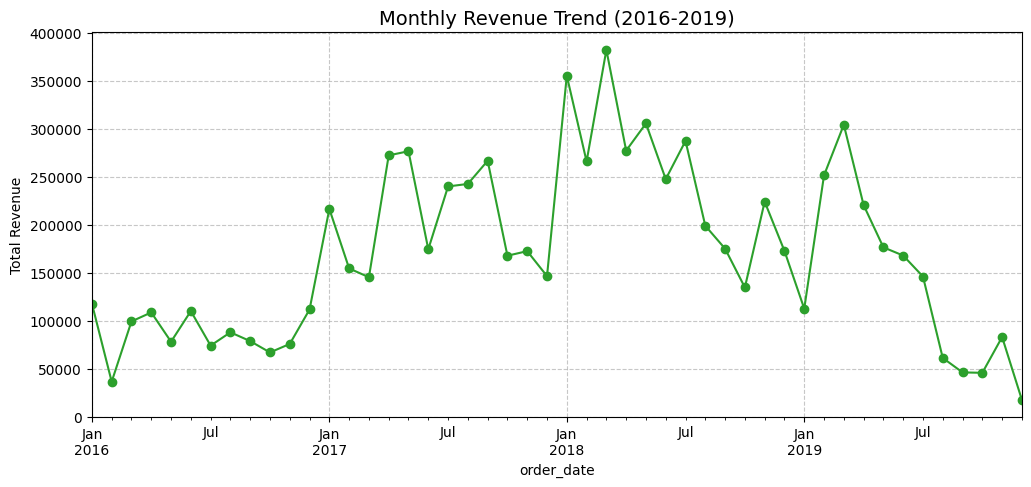

In [25]:
# We will look at the overall revenue, starting with the sales trends and YoY.
df_trend = df.set_index('order_date')

monthly_revenue = df_trend['revenue'].resample('M').sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o', color='#2ca02c')
plt.title('Monthly Revenue Trend (2016-2019)', fontsize=14)
plt.ylabel('Total Revenue')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [26]:
overall_yearly_revenue = df.pivot_table(
    index=df['order_date'].dt.year, 
    values='revenue', 
    aggfunc='sum'
)

overall_yearly_revenue['yoy_growth'] = overall_yearly_revenue['revenue'].pct_change() * 100
overall_yearly_revenue

,revenue,yoy_growth
order_date,,
2016,1045689.73,NaN
2017,2475119.06,136.697272
2018,3026001.67,22.256813
2019,1632666.74,-46.045412


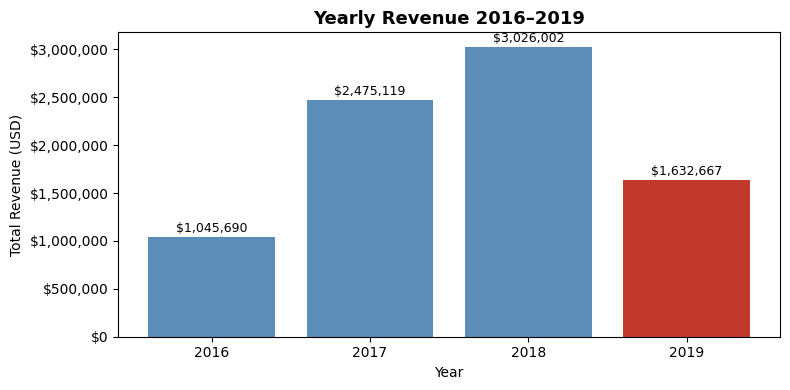

In [27]:
# Visualize yearly revenue to clearly show the growth and collapse pattern
yearly_rev = df.groupby(df['order_date'].dt.year)['revenue'].sum()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(yearly_rev.index.astype(str), yearly_rev.values, color=['#5B8DB8','#5B8DB8','#5B8DB8','#C0392B'])
ax.set_title('Yearly Revenue 2016–2019', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Revenue (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, yearly_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#### **4.2.2 Region Analysis — State & City**

In [28]:
regional_pivot = df.pivot_table(
    index='state', 
    values='revenue', 
    aggfunc='sum'
).sort_values(by='revenue', ascending=False)

regional_pivot['revenue_share_%'] = (regional_pivot['revenue'] / regional_pivot['revenue'].sum()) * 100

regional_pivot

,revenue,revenue_share_%
state,,
NY,5609292.41,68.577640
CA,1667430.67,20.385541
TX,902754.12,11.036819


In [29]:
city_pivot = df.pivot_table(
    index=['city','state'], 
    values='revenue', 
    aggfunc='sum'
).sort_values(by='revenue', ascending=False)

city_pivot['revenue_share_%'] = (city_pivot['revenue'] / city_pivot['revenue'].sum()) * 100

city_pivot.head(15)

,,revenue,revenue_share_%
city,state,,
Mount Vernon,NY,117010.21,1.430534
Ballston Spa,NY,110065.34,1.345628
San Angelo,TX,109729.26,1.341519
Orchard Park,NY,101189.27,1.237112
Baldwinsville,NY,90113.53,1.101703
Central Islip,NY,86516.50,1.057727
Smithtown,NY,85423.52,1.044364
Harlingen,TX,85284.58,1.042665
Monroe,NY,84418.40,1.032076


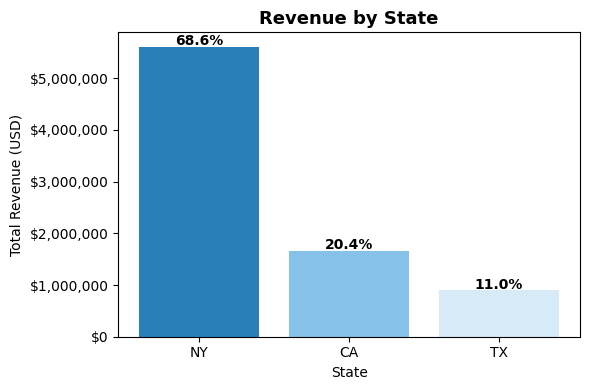

In [30]:
# Visualize revenue concentration by state
state_rev = df.groupby('state')['revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(state_rev.index, state_rev.values, color=['#2980B9','#85C1E9','#D6EAF8'])
ax.set_title('Revenue by State', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Total Revenue (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (state, val) in enumerate(state_rev.items()):
    pct = val / state_rev.sum() * 100
    ax.text(i, val + 30000, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

#### **4.2.3 Brand Analysis**

In [31]:
brand_pivot = df.pivot_table(
    index='brand_name', 
    values='revenue', 
    aggfunc='sum'
).sort_values(by='revenue', ascending=False)

brand_pivot['revenue_share_%'] = (brand_pivot['revenue'] / brand_pivot['revenue'].sum()) * 100

brand_pivot

,revenue,revenue_share_%
brand_name,,
Trek,4842662.73,59.205040
Electra,1287774.57,15.743972
Surly,1031993.91,12.616869
Sun Bicycles,372211.91,4.550559
Haro,204556.74,2.500853
Heller,183402.71,2.242230
Pure Cycles,165266.00,2.020496
Ritchey,88498.82,1.081962
Strider,3109.81,0.038020


In [32]:
# Price range per brand — explains why Trek revenue exceeds Electra
# despite Electra having higher total unit sales
df.groupby('brand_name')['unit_price'].describe()

,count,mean,std,min,25%,50%,75%,max
brand_name,,,,,,,,
Electra,1678.0,512.266466,3.465203e+02,269.99,299.99,499.99,599.99,2999.99
Haro,217.0,631.234240,4.572723e+02,209.99,249.99,379.99,869.99,1469.99
Heller,95.0,1374.800947,2.580235e+02,1320.99,1320.99,1320.99,1320.99,2599.00
Pure Cycles,256.0,441.890625,9.591855e+00,429.00,429.00,449.00,449.00,449.00
Ritchey,77.0,749.990000,2.288647e-13,749.99,749.99,749.99,749.99,749.99
Strider,12.0,163.323333,9.158536e+01,89.99,89.99,89.99,249.99,289.99
Sun Bicycles,470.0,531.992128,2.834494e+02,109.99,416.99,449.99,619.99,1559.99
Surly,591.0,1161.245770,5.458470e+02,469.99,749.99,999.99,1549.00,2499.99
Trek,1159.0,2785.943408,1.746061e+03,149.99,1499.99,2899.99,3999.99,11999.99


In [33]:
df.groupby('brand_name')['total_units'].agg(['sum']).sort_values(by='sum', ascending=False)

,sum
brand_name,
Electra,2534
Trek,1727
Surly,886
Sun Bicycles,709
Pure Cycles,374
Haro,326
Heller,134
Ritchey,118
Strider,19


In [34]:
df_2019 = df[df['order_date'].dt.year == 2019]

df_2019.groupby('brand_name')['total_units'].agg(['sum']).sort_values(by='sum', ascending=False)

,sum
brand_name,
Trek,413
Electra,390
Sun Bicycles,207
Surly,129
Haro,80
Pure Cycles,26
Heller,10
Ritchey,9
Strider,7


#### **4.2.4 Store Market Share**

In [35]:
# Market share check
store_market_share = df.pivot_table(
    index=df['order_date'].dt.year, 
    columns='store_name', 
    values='revenue', 
    aggfunc='sum'
).fillna(0)

store_market_share['Total_Revenue'] = store_market_share.sum(axis=1)

for store in ['Baldwin Bikes', 'Rowlett Bikes', 'Santa Cruz Bikes']:
    store_market_share[f'{store}_%'] = (store_market_share[store] / store_market_share['Total_Revenue']) * 100

store_market_share[[col for col in store_market_share.columns if '%' in col]]

store_name,Baldwin Bikes_%,Rowlett Bikes_%,Santa Cruz Bikes_%
order_date,,,
2016,63.534045,11.430341,25.035615
2017,69.189473,11.454602,19.355925
2018,67.949210,11.391252,20.659538
2019,72.045160,9.494510,18.460331


#### **4.2.5 Product & Category**

In [36]:
# Breakdown by Category
units_comparison_overall = df.pivot_table(
    index='category_name',
    columns=df['order_date'].dt.year,
    values='total_units',
    aggfunc='sum'
).fillna(0)

units_comparison_overall['total_units'] = units_comparison_overall.sum(axis=1)

units_comparison_overall = units_comparison_overall.sort_values(
    by='total_units', ascending=False
)
units_comparison_overall

order_date,2016,2017,2018,2019,total_units
category_name,,,,,
Cruisers Bicycles,402.0,595.0,675.0,343.0,2015.0
Mountain Bikes,280.0,567.0,578.0,275.0,1700.0
Children Bicycles,168.0,305.0,422.0,234.0,1129.0
Comfort Bicycles,129.0,250.0,258.0,149.0,786.0
Road Bikes,0.0,122.0,230.0,162.0,514.0
Cyclocross Bicycles,89.0,147.0,104.0,42.0,382.0
Electric Bikes,39.0,79.0,117.0,66.0,301.0


In [37]:
# Product and Category Check
category_over_time = df.pivot_table(
    index='category_name', 
    columns=df['order_date'].dt.year, 
    values='revenue', 
    aggfunc='sum'
).fillna(0)

category_over_time['Total_Revenue'] = category_over_time.sum(axis=1)
category_over_time = category_over_time.sort_values(by='Total_Revenue', ascending=False)

category_over_time

order_date,2016,2017,2018,2019,Total_Revenue
category_name,,,,,
Mountain Bikes,483311.20,982808.33,1042162.30,420044.35,2928326.18
Road Bikes,0.00,444428.78,725717.76,532493.47,1702640.01
Cruisers Bicycles,183331.34,291296.23,385730.19,213480.74,1073838.50
Electric Bikes,116999.61,251479.21,389578.83,212579.34,970636.99
Cyclocross Bicycles,143800.55,289223.06,222517.39,114488.67,770029.67
Comfort Bicycles,70848.71,130356.50,141509.42,78112.51,420827.14
Children Bicycles,47398.32,85526.95,118785.78,61467.66,313178.71


In [38]:
df.groupby('category_name')['unit_price'].describe()

,count,mean,std,min,25%,50%,75%,max
category_name,,,,,,,,
Children Bicycles,750.0,278.510000,76.847579,89.99,209.99,269.99,299.99,489.99
Comfort Bicycles,518.0,535.115483,122.512438,416.99,481.99,499.99,551.99,2599.99
Cruisers Bicycles,1347.0,535.628062,315.271537,250.99,416.99,489.99,599.99,2999.99
Cyclocross Bicycles,249.0,2017.098353,780.690218,1549.00,1549.00,1680.99,1680.99,3999.99
Electric Bikes,202.0,3185.336535,967.653534,1559.99,2999.99,2999.99,3499.99,4999.99
Mountain Bikes,1145.0,1722.287057,1324.931345,379.99,749.99,1320.99,2499.99,5299.99
Road Bikes,344.0,3313.847820,2019.647664,749.99,1499.99,2699.99,4999.99,11999.99


In [39]:
top_10_products_overall = df.groupby('product_name')['revenue'].sum().nlargest(10).reset_index()

product_info = df[['product_name', 'category_name',]].drop_duplicates()
top_10_products_overall = top_10_products_overall.merge(product_info, on='product_name', how='left')

top_10_products_overall

,product_name,revenue,category_name
0,Trek Slash 8 27.5 - 2016,603998.49,Mountain Bikes
1,Trek Conduit+ - 2016,431998.56,Electric Bikes
2,Trek Fuel EX 8 29 - 2016,414698.57,Mountain Bikes
3,Surly Straggler 650b - 2016,253829.49,Cyclocross Bicycles
4,Trek Domane SLR 6 Disc - 2017,236499.57,Road Bikes
5,Surly Straggler - 2016,226154.00,Cyclocross Bicycles
6,Trek Remedy 29 Carbon Frameset - 2016,221398.77,Mountain Bikes
7,Trek Powerfly 8 FS Plus - 2017,204999.59,Electric Bikes
8,Trek Silque SLR 8 Women's - 2017,188499.71,Road Bikes
9,Trek Madone 9.2 - 2017,184999.63,Road Bikes


#### **4.2.6 Sales Representative Performance**

In [40]:
# Analyze sales rep performance across years and stores
# This helps identify if performance gaps are driven by individual skill or store assignment
sales_rep_perf = df.pivot_table(
    index=['sales_rep','store_name'], 
    columns=df['order_date'].dt.year, 
    values='revenue', 
    aggfunc='sum'
).fillna(0)

sales_rep_perf['Total_Revenue'] = sales_rep_perf.sum(axis=1)
sales_rep_perf = sales_rep_perf.sort_values(by='Total_Revenue', ascending=False)
sales_rep_perf

,order_date,2016,2017,2018,2019,Total_Revenue
sales_rep,store_name,,,,,
Marcelene Boyer,Baldwin Bikes,296282.01,907190.47,1038275.45,588146.43,2829894.36
Venita Daniel,Baldwin Bikes,368086.97,805331.37,1017868.78,588110.93,2779398.05
Genna Serrano,Santa Cruz Bikes,136107.77,250534.01,321494.23,163191.70,871327.71
Mireya Copeland,Santa Cruz Bikes,125687.08,228548.17,303663.73,138203.98,796102.96
Kali Vargas,Rowlett Bikes,66045.45,127620.18,202702.45,69780.42,466148.50
Layla Terrell,Rowlett Bikes,53480.45,155894.86,141997.03,85233.28,436605.62


### **4.3 2019 Revenue Collapse — Deep Dive**

#### **4.3.1 Monthly Pattern Analysis**

In [41]:
# Analyze monthly revenue and transaction count in 2019
# A gradual month-over-month decline would suggest customer churn rather than a single event
monthly_2019 = df_2019.set_index('order_date').resample('M').agg({
    'revenue': 'sum', 
    'order_id': 'nunique'
})
monthly_2019.columns = ['total_revenue', 'transaction_count']
monthly_2019

C:\Users\muham\AppData\Local\Temp\ipykernel_21376\2022695774.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_2019 = df_2019.set_index('order_date').resample('M').agg({


,total_revenue,transaction_count
order_date,,
2019-01-31,112542.75,30
2019-02-28,251440.16,38
2019-03-31,304127.95,41
2019-04-30,220450.31,38
2019-05-31,176442.80,31
2019-06-30,167893.69,30
2019-07-31,146057.05,22
2019-08-31,61239.44,13
2019-09-30,46183.54,11


In [42]:
# Break down 2019 monthly revenue by store
# This reveals which stores went silent and when — pointing to operational rather than market issues
store_monthly_2019 = df_2019.groupby([df_2019['order_date'].dt.month, 'store_name'])['revenue'].sum().unstack()
store_monthly_2019

store_name,Baldwin Bikes,Rowlett Bikes,Santa Cruz Bikes
order_date,,,
1,86222.09,12835.85,13484.81
2,151457.97,72850.47,27131.72
3,205082.57,28438.72,70606.66
4,169233.77,24068.81,27147.73
5,106689.15,NaN,69753.65
6,140731.91,NaN,27161.78
7,141859.07,NaN,4197.98
8,51665.60,6519.93,3053.91
9,17229.81,939.98,28013.75


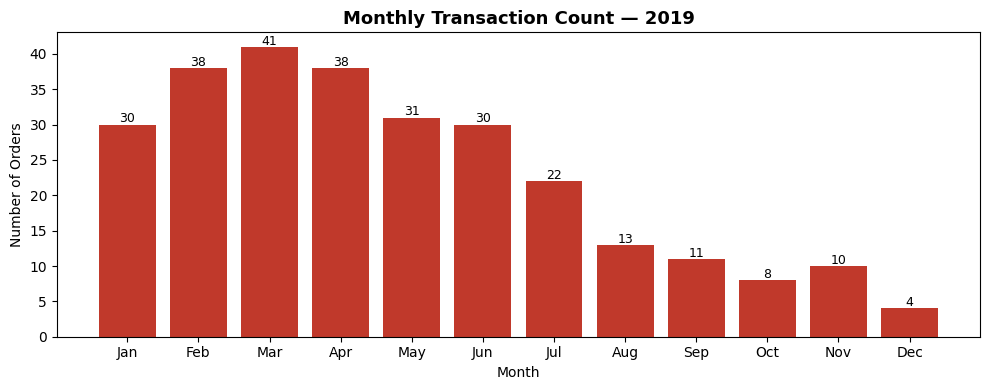

In [43]:
# Visualize the monthly transaction count in 2019 to show the gradual decline
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_2019.index.month, monthly_2019['transaction_count'], color='#C0392B')
ax.set_title('Monthly Transaction Count — 2019', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
for i, (month, row) in enumerate(monthly_2019.iterrows()):
    ax.text(month.month, row['transaction_count'] + 0.3, str(int(row['transaction_count'])),
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [44]:
# Create a 2018 vs 2019 comparison dataset for brand and category deep-dive
df_comparison = df[df['order_date'].dt.year.isin([2018, 2019])].copy()
df_comparison['year'] = df_comparison['order_date'].dt.year

# Units comparison by category and brand
units_comparison = df_comparison.pivot_table(
    index=['category_name', 'brand_name'], 
    columns='year', 
    values='total_units', 
    aggfunc='sum'
).fillna(0)

units_comparison['diff_units'] = units_comparison[2019] - units_comparison[2018]
units_comparison['pct_change'] = (units_comparison['diff_units'] / units_comparison[2018]) * 100
units_comparison.sort_values(by=2018, ascending=False)

,year,2018,2019,diff_units,pct_change
category_name,brand_name,,,,
Cruisers Bicycles,Electra,432,215,-217,-50.231481
Mountain Bikes,Trek,261,114,-147,-56.321839
Children Bicycles,Electra,246,102,-144,-58.536585
Road Bikes,Trek,198,135,-63,-31.818182
Mountain Bikes,Surly,167,85,-82,-49.101796
Comfort Bicycles,Electra,156,68,-88,-56.410256
Cruisers Bicycles,Sun Bicycles,149,102,-47,-31.543624
Comfort Bicycles,Sun Bicycles,102,81,-21,-20.588235
Cruisers Bicycles,Pure Cycles,94,26,-68,-72.340426


#### **4.3.2 Revenue Drop Overview (2018 vs 2019)**

In [45]:
# Overall revenue comparison — quantify the scale of the 2019 collapse
year_revenue_comparison = df_comparison.pivot_table(
    index='year', 
    values='revenue', 
    aggfunc='sum'
).fillna(0)

year_revenue_comparison['revenue_drop'] = year_revenue_comparison['revenue'].diff()
year_revenue_comparison['percentage'] = year_revenue_comparison['revenue'].pct_change() * 100
year_revenue_comparison

,revenue,revenue_drop,percentage
year,,,
2018,3026001.67,NaN,NaN
2019,1632666.74,-1393334.93,-46.045412


In [46]:
# Brand-level comparison: which brands drove the most revenue loss in 2019?
brand_comparison = df_comparison.pivot_table(
    index='brand_name', 
    columns='year', 
    values='revenue', 
    aggfunc='sum'
).fillna(0)

brand_comparison['revenue_drop'] = brand_comparison[2019] - brand_comparison[2018]
brand_comparison['percentage'] = (brand_comparison['revenue_drop'] / brand_comparison[2018]) * 100
brand_comparison.sort_values(by=2018, ascending=False)

year,2018,2019,revenue_drop,percentage
brand_name,,,,
Trek,1890853.26,1055665.87,-835187.39,-44.169868
Electra,462131.61,242546.01,-219585.60,-47.515815
Surly,319375.82,141525.96,-177849.86,-55.686702
Sun Bicycles,153170.13,106731.93,-46438.20,-30.318052
Haro,87578.60,50079.20,-37499.40,-42.817994
Heller,43506.71,17043.93,-26462.78,-60.824595
Pure Cycles,41606.00,11494.00,-30112.00,-72.374177
Ritchey,25499.66,6749.91,-18749.75,-73.529412
Strider,2279.88,829.93,-1449.95,-63.597645


In [47]:
# Units sold comparison by category — reveals demand shift beyond just revenue
units_cat_comparison = df_comparison.pivot_table(
    index='category_name', 
    columns='year', 
    values='total_units', 
    aggfunc='sum'
).fillna(0)
units_cat_comparison.sort_values(by=2018, ascending=False)

year,2018,2019
category_name,,
Cruisers Bicycles,675,343
Mountain Bikes,578,275
Children Bicycles,422,234
Comfort Bicycles,258,149
Road Bikes,230,162
Electric Bikes,117,66
Cyclocross Bicycles,104,42


In [48]:
category_comparison = df_comparison.pivot_table(
    index='category_name', 
    columns='year', 
    values='revenue', 
    aggfunc='sum'
).fillna(0)

category_comparison['revenue_drop'] = category_comparison[2019] - category_comparison[2018]
category_comparison['percentage'] = (category_comparison['revenue_drop'] / category_comparison[2018]) * 100

category_comparison.sort_values(by=2018, ascending=False)

year,2018,2019,revenue_drop,percentage
category_name,,,,
Mountain Bikes,1042162.30,420044.35,-622117.95,-59.694920
Road Bikes,725717.76,532493.47,-193224.29,-26.625267
Electric Bikes,389578.83,212579.34,-176999.49,-45.433549
Cruisers Bicycles,385730.19,213480.74,-172249.45,-44.655424
Cyclocross Bicycles,222517.39,114488.67,-108028.72,-48.548439
Comfort Bicycles,141509.42,78112.51,-63396.91,-44.800487
Children Bicycles,118785.78,61467.66,-57318.12,-48.253352


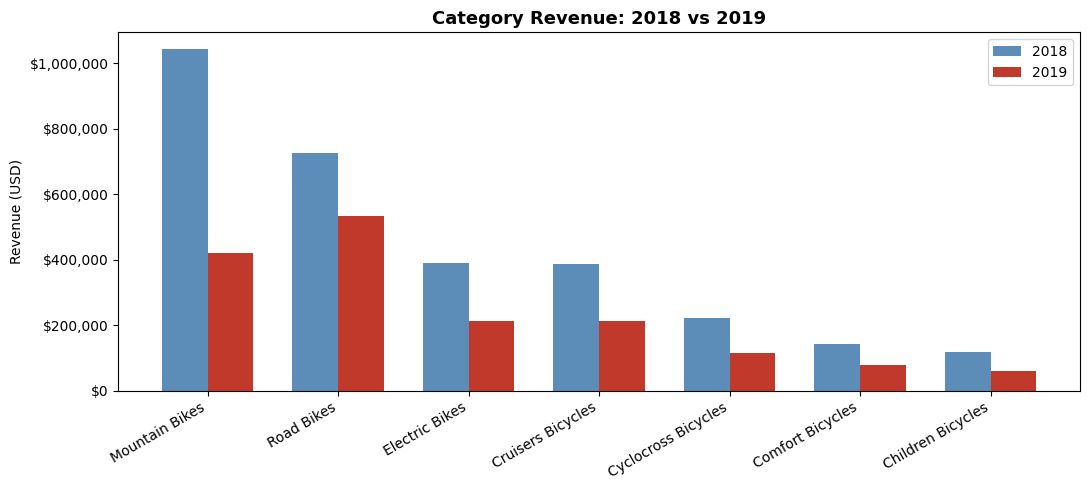

In [49]:
# Visualize how each category performed in 2018 vs 2019
# This immediately shows which categories were hit hardest
cat_plot = category_comparison[[2018, 2019]].sort_values(by=2018, ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(cat_plot))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], cat_plot[2018], width, label='2018', color='#5B8DB8')
bars2 = ax.bar([i + width/2 for i in x], cat_plot[2019], width, label='2019', color='#C0392B')
ax.set_title('Category Revenue: 2018 vs 2019', fontsize=13, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels(cat_plot.index, rotation=30, ha='right')
ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
# Product-level comparison: top 10 products by 2018 revenue and their 2019 performance
product_comparison = df_comparison.pivot_table(
    index=['product_name', 'category_name'], 
    columns='year', 
    values='revenue', 
    aggfunc='sum'
).fillna(0)

product_comparison['revenue_drop'] = product_comparison[2019] - product_comparison[2018]
product_comparison['percentage'] = (product_comparison['revenue_drop'] / product_comparison[2018]) * 100
product_comparison.sort_values(by=2018, ascending=False).head(10)

,year,2018,2019,revenue_drop,percentage
product_name,category_name,,,,
Trek Slash 8 27.5 - 2016,Mountain Bikes,135999.66,43999.89,-91999.77,-67.647059
Trek Fuel EX 8 29 - 2016,Mountain Bikes,118899.59,28999.90,-89899.69,-75.609756
Trek Conduit+ - 2016,Electric Bikes,113999.62,26999.91,-86999.71,-76.315789
Trek Powerfly 8 FS Plus - 2017,Electric Bikes,104999.79,34999.93,-69999.86,-66.666667
Trek Fuel EX 9.8 27.5 Plus - 2017,Mountain Bikes,100699.81,15899.97,-84799.84,-84.210526
Trek Domane SLR 6 Disc - 2017,Road Bikes,98999.82,38499.93,-60499.89,-61.111111
Trek Fuel EX 9.8 29 - 2017,Mountain Bikes,79999.84,39999.92,-39999.92,-50.000000
Trek Silque SLR 7 Women's - 2017,Road Bikes,77999.87,41999.93,-35999.94,-46.153846
Trek Silque SLR 8 Women's - 2017,Road Bikes,71499.89,38999.94,-32499.95,-45.454545


In [51]:
# Revenue contribution of Electric Bikes by product
electric = df[df['category_name'] == 'Electric Bikes'].groupby('product_name')['revenue'].sum().sort_values(ascending=False)
electric

product_name
Trek Conduit+ - 2016                         431998.56
Trek Powerfly 8 FS Plus - 2017               204999.59
Sun Bicycles ElectroLite - 2017               53039.66
Trek Powerfly 7 FS - 2018                     29999.94
Trek Super Commuter+ 8S - 2018                29999.94
Trek Super Commuter+ 7 - 2018                 28799.92
Trek XM700+ - 2018                            27999.92
Trek XM700+ Lowstep - 2018                    24499.93
Trek Conduit+ - 2018                          19599.93
Electra Townie Commute Go! - 2018             17999.94
Trek Powerfly 5 Women's - 2018                17499.95
Trek Lift+ - 2018                             13999.95
Trek CrossRip+ - 2018                         13499.97
Trek Verve+ - 2018                            11499.95
Trek Dual Sport+ - 2018                       11199.96
Trek Verve+ Lowstep - 2018                     6899.97
Electra Townie Commute Go! Ladies' - 2018      5999.98
Trek Lift+ Lowstep - 2018                      5599.

In [52]:
top10_all = df.groupby(['product_name', 'category_name'])[['revenue', 'total_units']].sum().sort_values('revenue', ascending=False).head(10).reset_index()
top10_all

,product_name,category_name,revenue,total_units
0,Trek Slash 8 27.5 - 2016,Mountain Bikes,603998.49,151
1,Trek Conduit+ - 2016,Electric Bikes,431998.56,144
2,Trek Fuel EX 8 29 - 2016,Mountain Bikes,414698.57,143
3,Surly Straggler 650b - 2016,Cyclocross Bicycles,253829.49,151
4,Trek Domane SLR 6 Disc - 2017,Road Bikes,236499.57,43
5,Surly Straggler - 2016,Cyclocross Bicycles,226154.00,146
6,Trek Remedy 29 Carbon Frameset - 2016,Mountain Bikes,221398.77,123
7,Trek Powerfly 8 FS Plus - 2017,Electric Bikes,204999.59,41
8,Trek Silque SLR 8 Women's - 2017,Road Bikes,188499.71,29
9,Trek Madone 9.2 - 2017,Road Bikes,184999.63,37


In [53]:
# Geographic deep dive: which cities lost the most revenue from 2018 to 2019?
city_comparison = df_comparison.pivot_table(
    index=['state','city'], 
    columns='year', 
    values='revenue', 
    aggfunc='sum'
).fillna(0)

city_comparison['revenue_drop'] = city_comparison[2019] - city_comparison[2018]
city_comparison['percentage'] = ((city_comparison[2019] - city_comparison[2018]) / city_comparison[2018]) * 100
city_comparison.sort_values(by=2018, ascending=False).head(15)

year                      2018      2019  revenue_drop  percentage
state city                                                        
NY    Baldwinsville   68864.66  11099.94     -57764.72  -83.881515
      Howard Beach    61906.73   8303.91     -53602.82  -86.586418
CA    San Lorenzo     56853.62   1359.96     -55493.66  -97.607962
NY    Floral Park     48396.79   1349.97     -47046.82  -97.210621
      Sunnyside       46947.67   4797.91     -42149.76  -89.780302
TX    Houston         45942.74      0.00     -45942.74 -100.000000
NY    Amityville      42021.85  25240.83     -16781.02  -39.934034
      Astoria         41013.80  23796.83     -17216.97  -41.978480
      Bay Shore       40113.78      0.00     -40113.78 -100.000000
      New Rochelle    39494.75      0.00     -39494.75 -100.000000
TX    Longview        39128.74   1703.97     -37424.77  -95.645221
      San Angelo      38433.73  24903.83     -13529.90  -35.203193
NY    Merrick         37816.79  13053.85     -24762.94  -65.481338
TX    Corpus Christi  37607.71   2513.94     -35093.77  -93.315360
NY    Monsey          34881.77      0.00     -34881.77 -100.000000

### **5. Export Clean Data**

In [41]:
# Export the cleaned dataset back to PostgreSQL for use in Power BI
df_clean = df.drop(columns=['sales_group'], errors='ignore')
df_clean.to_sql(
    "bike_sales_clean",
    engine,
    schema="bike_sales",
    if_exists="replace",
    index=False,
    method="multi"
)
print(f"Export successful. Rows exported: {len(df_clean)}")

4555